<h1 style='color:#5BC0EB'>PTB-XL: reconstrucción de señales ECG</h1>

<h2 style='color:#5BC0EB'>1. El problema que queremos resolver</h2>
<p style='color:#b0b0b0'>Un electrocardiógrafo hospitalario registra la actividad eléctrica del corazón a <strong>500 Hz</strong>, un punto de medición cada 2 ms. Un equipo de clínica básica (Contec, Biocare, y la mayoría de los dispositivos portátiles de bajo costo) registra a <strong>100–150 Hz</strong>, un punto cada 7–10 ms.</p>
<p style='color:#b0b0b0'>La diferencia de precio entre ambos equipos es de 5 a 30 veces. Y la diferencia clínica es real: el complejo QRS (el evento que indica si hay infarto o arritmia) dura solo 80–120 ms. A 100 Hz ese evento queda capturado con apenas <strong>10 puntos</strong>. A 500 Hz, con <strong>50 puntos</strong>. Con 10 puntos el pico puede desplazarse, el notching desaparecer, y el intervalo QTc medirse con error.</p>
<blockquote style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); color:#e8c97a; padding:10px 14px; margin:8px 0'>
<strong>Pregunta central del proyecto:</strong> ¿Podemos reconstruir una señal ECG de 500 Hz a partir de una de 100 Hz con error clínicamente tolerable, usando métodos de ajuste de curvas que elijan automáticamente el mejor modelo por región fisiológica?
</blockquote>

<h3 style='color:#A8D8EA'>El par entrada / ground truth ya existe en PTB-XL</h3>
<p style='color:#b0b0b0'>Normalmente, para entrenar o evaluar un sistema de reconstrucción hay que simular la señal degradada a partir de la buena. PTB-XL tiene ese par de forma nativa: cada uno de sus 21,799 registros existe en <em>dos versiones del mismo momento de medición</em>, una a 100 Hz y una a 500 Hz. Mismo paciente, mismo electrodo, misma toma. Podemos evaluar la reconstrucción contra el ground truth real, no simulado.</p>

In [20]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import wfdb
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline

DATA_DIR = 'ptbxl_data'

meta = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_database.csv'), index_col='ecg_id')
scp_info = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)
scp_to_super = scp_info[scp_info['diagnostic'] == 1]['diagnostic_class'].to_dict()

def get_superclass(scp_str):
    try:
        codes = ast.literal_eval(scp_str)
    except Exception:
        return 'UNKNOWN'
    diag = {k: v for k, v in codes.items() if k in scp_to_super}
    if not diag:
        return 'OTHER'
    return scp_to_super[max(diag, key=diag.get)]

meta['superclass'] = meta['scp_codes'].apply(get_superclass)
print(f'Registros totales en PTB-XL: {len(meta):,}')
print(f'Descargados en notebook 1:   500')
print(f'Pendientes de descargar:     {len(meta) - 500:,}')

Registros totales en PTB-XL: 21,799
Descargados en notebook 1:   500
Pendientes de descargar:     21,299


<h2 style='color:#5BC0EB'>2. El dataset</h2>
<p style='color:#b0b0b0'>PTB-XL tiene 21,799 registros de 18,869 pacientes distintos. Cada registro fue etiquetado por al menos un cardiólogo con un código diagnóstico SCP, y 16,056 de ellos fueron validados por un segundo cardiólogo. Las etiquetas se agrupan en cinco superclases diagnósticas más una categoría residual.</p>

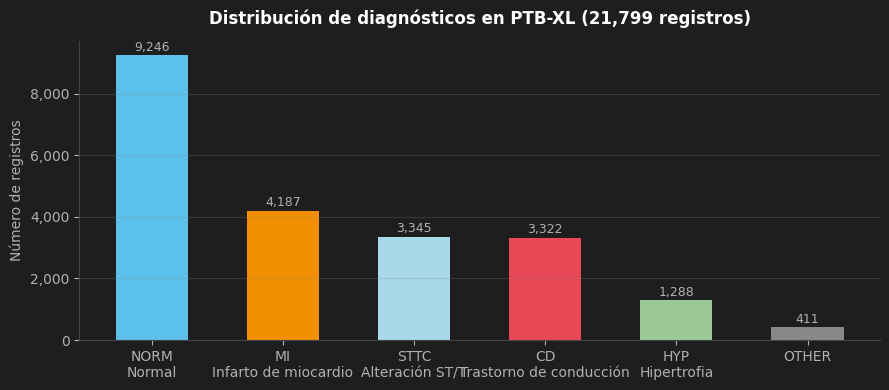

In [11]:
counts = meta['superclass'].value_counts()

labels_full = {
    'NORM': 'NORM\nNormal',
    'MI':   'MI\nInfarto de miocardio',
    'STTC': 'STTC\nAlteración ST/T',
    'CD':   'CD\nTrastorno de conducción',
    'HYP':  'HYP\nHipertrofia',
    'OTHER': 'OTHER'}

bar_colors = ['#5BC0EB', '#F18F01', '#A8D8EA', '#E84855', '#9BC995', '#888888']

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

bars = ax.bar(
    [labels_full.get(k, k) for k in counts.index],
    counts.values,
    color=bar_colors[:len(counts)],
    edgecolor='none',
    width=0.55)

for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f'{val:,}',
        ha='center', va='bottom', fontsize=9, color='#b0b0b0')

ax.set_title('Distribución de diagnósticos en PTB-XL (21,799 registros)', fontweight='bold', color='white', pad=12)
ax.set_ylabel('Número de registros', color='#b0b0b0')
ax.tick_params(colors='#b0b0b0')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.grid(axis='y', alpha=0.25, color='#888')
plt.tight_layout()
plt.show()

<h3 style='color:#A8D8EA'>Qué se ve en el ECG de cada clase</h3>
<p style='color:#b0b0b0'>Los números de arriba no dicen mucho si no se sabe qué separa un ritmo normal de un infarto o un trastorno de conducción. Abajo se muestra la derivación II de un registro real por clase, 4 segundos a 500 Hz. No hace falta leer ECG para notar que la morfología cambia: la amplitud, la anchura del pico, la forma de la onda T, la regularidad del ritmo. Esas diferencias son exactamente lo que queremos preservar al reconstruir la señal.</p>

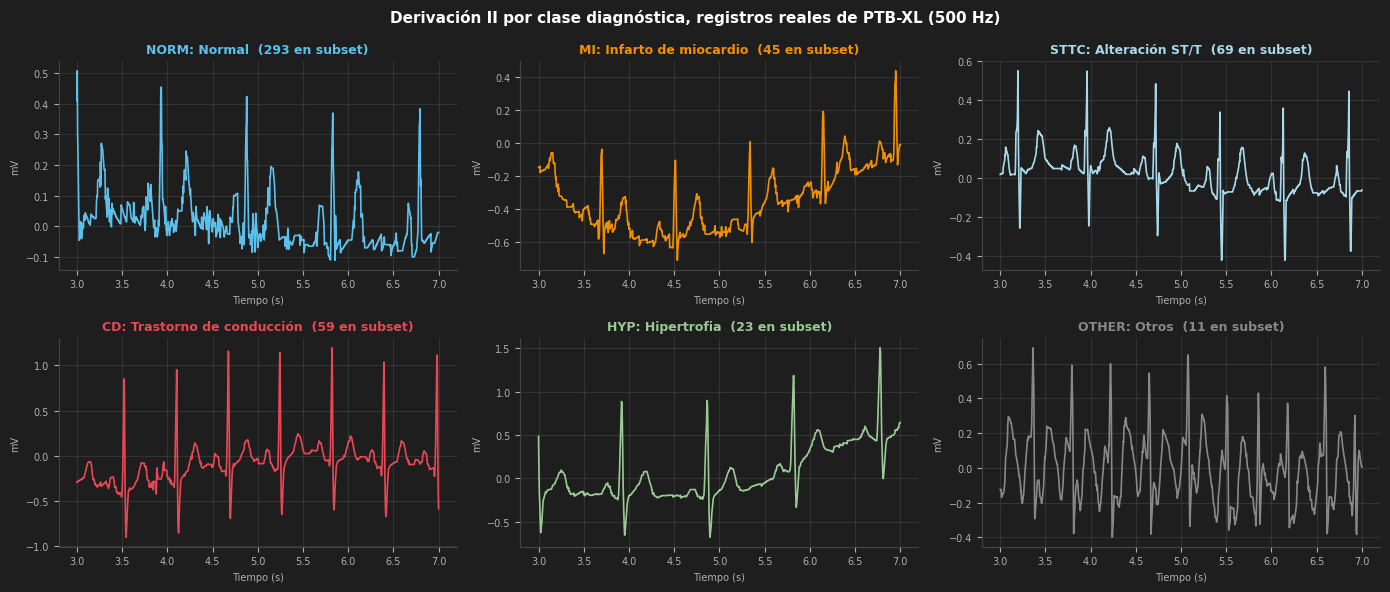

In [21]:
# Un registro representativo por clase diagnóstica (derivación II, 500 Hz, 4 segundos)
subset500 = meta.iloc[:500].copy()
subset500['superclass'] = subset500['scp_codes'].apply(get_superclass)

target_classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP', 'OTHER']
class_labels = {
    'NORM': 'Normal',
    'MI':   'Infarto de miocardio',
    'STTC': 'Alteración ST/T',
    'CD':   'Trastorno de conducción',
    'HYP':  'Hipertrofia',
    'OTHER': 'Otros'}
class_colors = ['#5BC0EB', '#F18F01', '#A8D8EA', '#E84855', '#9BC995', '#888888']

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()
fig.patch.set_facecolor('#1e1e1e')

for idx, cls in enumerate(target_classes):
    ax = axes[idx]
    ax.set_facecolor('#1e1e1e')
    color = class_colors[idx]

    records = subset500[subset500['superclass'] == cls]
    if len(records) == 0:
        ax.text(0.5, 0.5, 'sin registros en el subset',
                ha='center', va='center', color='#888', transform=ax.transAxes)
        ax.set_title(f'{cls}: {class_labels[cls]}', color=color, fontweight='bold', fontsize=9)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#444'); ax.spines['bottom'].set_color('#444')
        continue

    row = records.iloc[0]
    path_hr = os.path.join(DATA_DIR, row['filename_hr'])
    sig, _ = wfdb.rdsamp(path_hr)
    lead = sig[:, 1]  # Derivación II

    t = np.arange(len(lead)) / 500
    mask = (t >= 3.0) & (t <= 7.0)

    ax.plot(t[mask], lead[mask], color=color, lw=1.2)
    ax.set_title(
        f'{cls}: {class_labels[cls]}  ({len(records)} en subset)',
        color=color, fontweight='bold', fontsize=9)
    ax.set_xlabel('Tiempo (s)', color='#b0b0b0', fontsize=7)
    ax.set_ylabel('mV', color='#b0b0b0', fontsize=7)
    ax.tick_params(colors='#b0b0b0', labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.grid(alpha=0.2, color='#888')

plt.suptitle('Derivación II por clase diagnóstica, registros reales de PTB-XL (500 Hz)',
             fontweight='bold', color='white', fontsize=11)
plt.tight_layout()
plt.show()

<h3 style='color:#A8D8EA'>Sobre el desbalance de clases</h3>
<p style='color:#b0b0b0'>La distribución no está balanceada: casi la mitad de los registros son normales (NORM = 9,246) y la clase más pequeña tiene solo 411 casos. Esto es esperable; en la práctica clínica, la mayoría de los ECG tomados son normales.</p>
<p style='color:#b0b0b0'>Para nuestro proyecto esto no es un problema de entrada, por dos razones:</p>
<ol style='color:#b0b0b0'>
<li>La tarea de <em>reconstrucción de señal</em> es no supervisada en cuanto a etiqueta diagnóstica: no clasificamos, reconstruimos. Cada registro aporta un par (100 Hz, 500 Hz) independientemente de su diagnóstico.</li>
<li>Si queremos evaluar que la reconstrucción <em>preserva características diagnósticas</em> por clase (por ejemplo, que el ST elevado de un infarto no desaparece al reconstruir), sí necesitaremos muestras de cada clase. Con los 500 registros descargados hay representación de todas las clases para empezar.</li>
</ol>
<blockquote style='border-left:4px solid #5BC0EB; background:rgba(91,192,235,0.08); color:#A8D8EA; padding:10px 14px; margin:8px 0'>
<strong>Nota técnica:</strong> Descargamos 500 de los 21,799 registros disponibles. Quedan 21,299 sin descargar (~2.8 GB adicionales).
</blockquote>

<h2 style='color:#5BC0EB'>3. Anatomía de la señal ECG</h2>
<p style='color:#b0b0b0'>Antes de hablar de los métodos matemáticos hay que entender qué tiene la señal. Un ciclo cardíaco de 10 segundos contiene entre 6 y 12 latidos. Cada latido tiene exactamente la misma estructura de tres regiones, y cada región tiene una forma geométrica distinta. Esa diferencia de forma es la que justifica usar métodos distintos.</p>

In [12]:
ECG_ID = meta.index[0]
row = meta.loc[ECG_ID]

path_lr = os.path.join(DATA_DIR, row['filename_lr'])
path_hr = os.path.join(DATA_DIR, row['filename_hr'])
signal_lr, _ = wfdb.rdsamp(path_lr)
signal_hr, _ = wfdb.rdsamp(path_hr)

LEAD = 1  # Derivación II, la más usada en clínica
lead_hr = signal_hr[:, LEAD]
lead_lr = signal_lr[:, LEAD]

t_lr = np.arange(len(lead_lr)) / 100
t_hr = np.arange(len(lead_hr)) / 500

r_idx = int(np.argmax(lead_hr))
r_time = r_idx / 500

print(f'Registro: ECG ID {ECG_ID}  |  diagnóstico: {row["superclass"]}')
print(f'Señal 100 Hz: {signal_lr.shape[0]} muestras  |  Señal 500 Hz: {signal_hr.shape[0]} muestras')
print(f'Pico R en t = {r_time:.3f} s  (muestra {r_idx} a 500 Hz)')

Registro: ECG ID 1  |  diagnóstico: NORM
Señal 100 Hz: 1000 muestras  |  Señal 500 Hz: 5000 muestras
Pico R en t = 3.004 s  (muestra 1502 a 500 Hz)


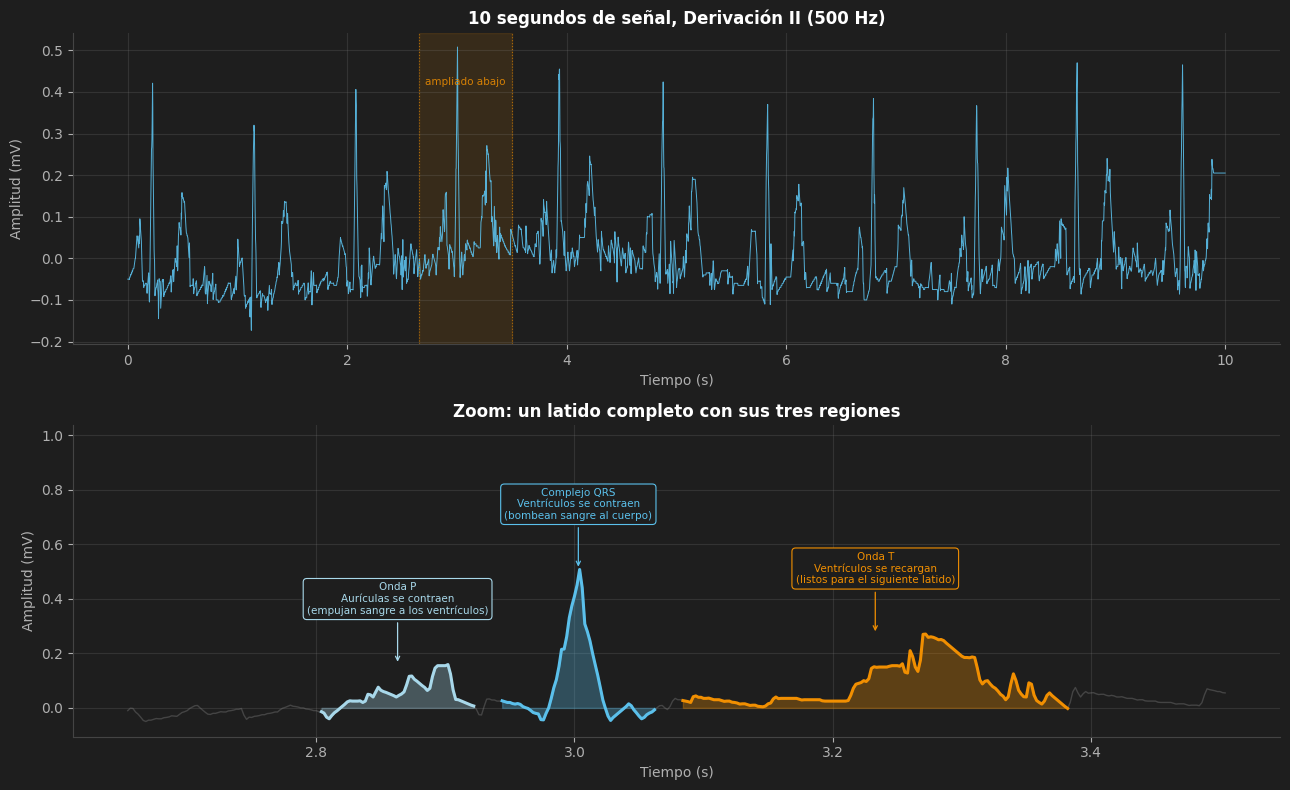

In [22]:
zoom_s = max(0, r_time - 0.35)
zoom_e = min(10.0, r_time + 0.5)

fig = plt.figure(figsize=(13, 8))
fig.patch.set_facecolor('#1e1e1e')

# Panel superior: los 10 segundos completos
ax1 = fig.add_subplot(2, 1, 1)
ax1.set_facecolor('#1e1e1e')
ax1.plot(t_hr, lead_hr, color='#5BC0EB', lw=0.7, alpha=0.9)
ax1.axvspan(zoom_s, zoom_e, color='#F18F01', alpha=0.12)
ax1.axvline(zoom_s, color='#F18F01', lw=0.8, linestyle=':', alpha=0.6)
ax1.axvline(zoom_e, color='#F18F01', lw=0.8, linestyle=':', alpha=0.6)
ax1.text((zoom_s + zoom_e) / 2, float(lead_hr.max()) * 0.82,
         'ampliado abajo', ha='center', color='#F18F01', fontsize=7.5, alpha=0.85)
ax1.set_title('10 segundos de señal, Derivación II (500 Hz)', fontweight='bold', color='white')
ax1.set_xlabel('Tiempo (s)', color='#b0b0b0')
ax1.set_ylabel('Amplitud (mV)', color='#b0b0b0')
ax1.tick_params(colors='#b0b0b0')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#444')
ax1.spines['bottom'].set_color('#444')
ax1.grid(alpha=0.2, color='#888')

# Panel inferior: zoom de un latido con P / QRS / T y significado fisiológico
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_facecolor('#1e1e1e')

mask = (t_hr >= zoom_s) & (t_hr <= zoom_e)
t_win = t_hr[mask]
sig_win = lead_hr[mask]
y_min = float(sig_win.min())
y_max = float(sig_win.max())
y_range = y_max - y_min

def ms2idx(ms):
    return int(ms / 1000 * 500)

region_config = [
    ('Onda P',
     max(0, r_idx - ms2idx(200)), max(0, r_idx - ms2idx(80)),
     '#A8D8EA',
     'Aurículas se contraen\n(empujan sangre a los ventrículos)'),
    ('Complejo QRS',
     max(0, r_idx - ms2idx(60)), min(len(lead_hr), r_idx + ms2idx(60)),
     '#5BC0EB',
     'Ventrículos se contraen\n(bombean sangre al cuerpo)'),
    ('Onda T',
     min(len(lead_hr), r_idx + ms2idx(80)), min(len(lead_hr), r_idx + ms2idx(380)),
     '#F18F01',
     'Ventrículos se recargan\n(listos para el siguiente latido)')]

ax2.plot(t_win, sig_win, color='#444444', lw=1.0, zorder=1)

for name, s, e, color, desc in region_config:
    rm = np.zeros(len(t_hr), dtype=bool)
    rm[s:e] = True
    rm &= mask
    if not rm.any():
        continue
    ax2.fill_between(t_hr, lead_hr, alpha=0.3, where=rm, color=color, zorder=2)
    ax2.plot(t_hr[rm], lead_hr[rm], color=color, lw=2.2, zorder=3)
    x_c = float(t_hr[rm].mean())
    y_top = float(lead_hr[rm].max())
    ax2.annotate(
        f'{name}\n{desc}',
        xy=(x_c, y_top),
        xytext=(x_c, y_top + y_range * 0.32),
        ha='center', va='bottom', color=color, fontsize=7.5,
        arrowprops=dict(arrowstyle='->', color=color, lw=0.9),
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#1e1e1e',
                  edgecolor=color, linewidth=0.8))

ax2.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.95)
ax2.set_title('Zoom: un latido completo con sus tres regiones', fontweight='bold', color='white')
ax2.set_xlabel('Tiempo (s)', color='#b0b0b0')
ax2.set_ylabel('Amplitud (mV)', color='#b0b0b0')
ax2.tick_params(colors='#b0b0b0')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#444')
ax2.spines['bottom'].set_color('#444')
ax2.grid(alpha=0.2, color='#888')

plt.tight_layout()
plt.show()

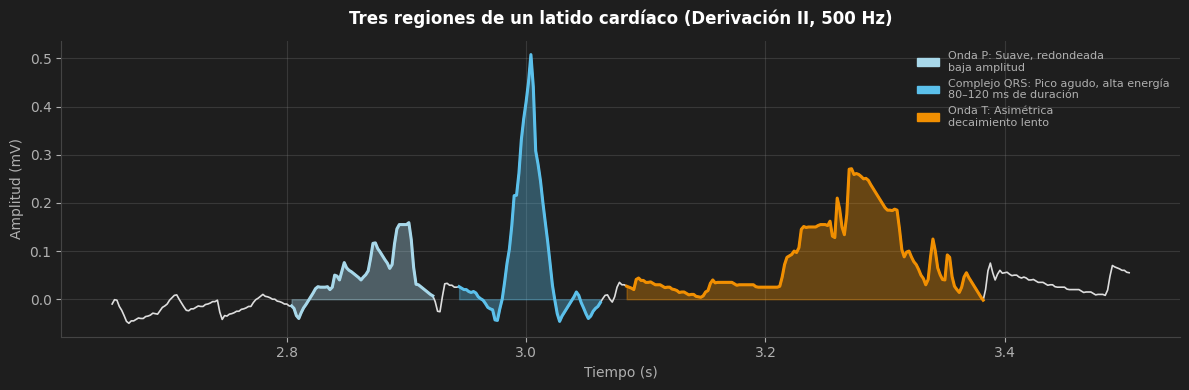

In [13]:
def ms2s(ms, fs=500):
    return int(ms / 1000 * fs)

r = r_idx
regions = {
    'Onda P':       (max(0, r - ms2s(200)), max(0, r - ms2s(80)),  '#A8D8EA', 'Suave, redondeada\nbaja amplitud'),
    'Complejo QRS': (max(0, r - ms2s(60)),  min(len(lead_hr), r + ms2s(60)),  '#5BC0EB', 'Pico agudo, alta energía\n80–120 ms de duración'),
    'Onda T':       (min(len(lead_hr), r + ms2s(80)),  min(len(lead_hr), r + ms2s(380)), '#F18F01', 'Asimétrica\ndecaimiento lento')}

zoom_s = max(0, r_time - 0.35)
zoom_e = min(10, r_time + 0.5)
mask = (t_hr >= zoom_s) & (t_hr <= zoom_e)

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

ax.plot(t_hr[mask], lead_hr[mask], color='#dddddd', lw=1.2, zorder=2)

patches = []
for name, (s, e, color, desc) in regions.items():
    region_mask = np.zeros(len(t_hr), dtype=bool)
    region_mask[s:e] = True
    region_mask &= mask
    ax.fill_between(t_hr, lead_hr, alpha=0.35, where=region_mask, color=color, zorder=3)
    ax.plot(t_hr[region_mask], lead_hr[region_mask], color=color, lw=2.2, zorder=4)
    patches.append(mpatches.Patch(color=color, label=f'{name}: {desc}'))

ax.set_title('Tres regiones de un latido cardíaco (Derivación II, 500 Hz)', fontweight='bold', color='white', pad=12)
ax.set_xlabel('Tiempo (s)', color='#b0b0b0')
ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')
ax.legend(handles=patches, framealpha=0, labelcolor='#b0b0b0', fontsize=8, loc='upper right')
ax.tick_params(colors='#b0b0b0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.grid(alpha=0.25, color='#888')
plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB'>4. Los tres métodos matemáticos</h2>
<p style='color:#b0b0b0'>La idea central del proyecto es que ningún método de ajuste de curvas es óptimo para las tres regiones. En lugar de elegir uno globalmente, elegimos el mejor para cada segmento del latido. Aquí mostramos los tres métodos sobre datos reales de PTB-XL: tomamos la señal de 500 Hz, la submuestreamos a 100 Hz (simulando el equipo básico), y aplicamos cada método para reconstruir los 500 Hz originales.</p>

In [23]:
def extract_segment(signal, center_idx, before_ms, after_ms, fs=500):
    s = max(0, center_idx - int(before_ms / 1000 * fs))
    e = min(len(signal), center_idx + int(after_ms / 1000 * fs))
    seg = signal[s:e]
    t_dense = np.arange(len(seg)) / fs * 1000  # en ms
    return t_dense, seg, s, e

def downsample(t_dense, seg, fs_orig=500, fs_target=100):
    step = fs_orig // fs_target
    t_sparse = t_dense[::step]
    seg_sparse = seg[::step]
    return t_sparse, seg_sparse

def gauss_sum(x, *params):
    y = np.zeros_like(x, dtype=float)
    for i in range(0, len(params), 3):
        A, mu, sigma = params[i], params[i+1], params[i+2]
        y += A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    return y

print('Funciones de reconstrucción definidas.')

Funciones de reconstrucción definidas.


<h3 style='color:#A8D8EA'>Método 1: ajuste polinomial en la onda P</h3>
<p style='color:#b0b0b0'>La onda P es la más suave del ciclo. Tiene un solo arco de baja amplitud sin discontinuidades. Un polinomio de grado bajo puede capturar esa forma sin sobreajustar, porque no necesita flexibilidad local. Aquí usamos grado 6: suficiente para seguir la curvatura sin oscilar.</p>

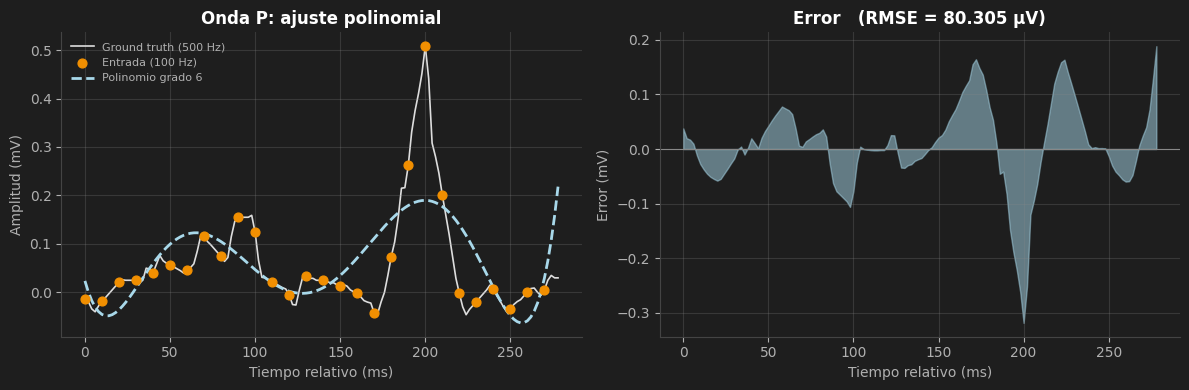

In [15]:
t_p, seg_p, _, _ = extract_segment(lead_hr, r, before_ms=200, after_ms=80)
t_p_sparse, seg_p_sparse = downsample(t_p, seg_p)

deg = 6
coeffs = np.polyfit(t_p_sparse, seg_p_sparse, deg)
p_reconstructed = np.polyval(coeffs, t_p)

rmse_poly = np.sqrt(np.mean((p_reconstructed - seg_p) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1e1e1e')

for ax in axes:
    ax.set_facecolor('#1e1e1e')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.tick_params(colors='#b0b0b0')
    ax.grid(alpha=0.25, color='#888')
    ax.set_xlabel('Tiempo relativo (ms)', color='#b0b0b0')
    ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')

ax = axes[0]
ax.plot(t_p, seg_p, color='#dddddd', lw=1.2, label='Ground truth (500 Hz)', zorder=1)
ax.scatter(t_p_sparse, seg_p_sparse, color='#F18F01', s=40, zorder=3, label='Entrada (100 Hz)')
ax.plot(t_p, p_reconstructed, color='#A8D8EA', lw=2, linestyle='--', label=f'Polinomio grado {deg}', zorder=2)
ax.set_title('Onda P: ajuste polinomial', fontweight='bold', color='white')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)

ax = axes[1]
error = p_reconstructed - seg_p
ax.fill_between(t_p, error, alpha=0.5, color='#A8D8EA')
ax.axhline(0, color='#888', lw=0.8)
ax.set_title(f'Error   (RMSE = {rmse_poly*1000:.3f} µV)', fontweight='bold', color='white')
ax.set_ylabel('Error (mV)', color='#b0b0b0')
ax.set_xlabel('Tiempo relativo (ms)', color='#b0b0b0')

plt.tight_layout()
plt.show()

<h3 style='color:#A8D8EA'>Método 2: suma de gaussianas en el complejo QRS</h3>
<p style='color:#b0b0b0'>El QRS es un pico estrecho y simétrico. Una gaussiana (o suma de dos si el complejo tiene notching) captura esa forma de forma natural porque comparte la misma geometría: campana centrada, cola que decae rápido. Un polinomio aquí oscila entre los pocos puntos disponibles; un spline queda rígido porque los nodos son muy escasos.</p>

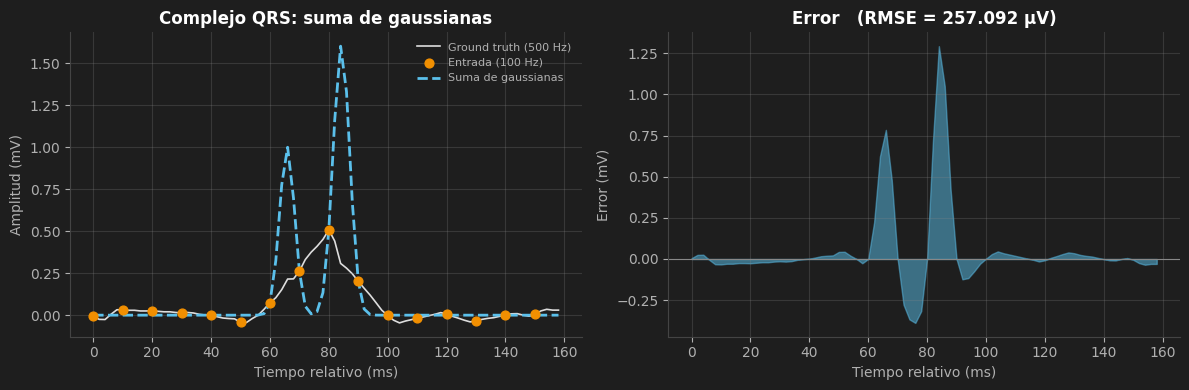

In [16]:
t_q, seg_q, _, _ = extract_segment(lead_hr, r, before_ms=80, after_ms=80)
t_q_sparse, seg_q_sparse = downsample(t_q, seg_q)

t_mid = t_q[len(t_q) // 2]
A_init = float(seg_q.max() - seg_q.min())
p0 = [A_init, t_mid, 15, A_init * 0.3, t_mid - 10, 8]
try:
    popt, _ = curve_fit(
        gauss_sum, t_q_sparse, seg_q_sparse,
        p0=p0, maxfev=8000,
        bounds=([-np.inf, 0, 1, -np.inf, 0, 1], [np.inf, 200, 80, np.inf, 200, 80]))
    q_reconstructed = gauss_sum(t_q, *popt)
except Exception:
    p0_simple = [A_init, t_mid, 20]
    popt, _ = curve_fit(gauss_sum, t_q_sparse, seg_q_sparse, p0=p0_simple, maxfev=8000)
    q_reconstructed = gauss_sum(t_q, *popt)

rmse_gauss = np.sqrt(np.mean((q_reconstructed - seg_q) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1e1e1e')

for ax in axes:
    ax.set_facecolor('#1e1e1e')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.tick_params(colors='#b0b0b0')
    ax.grid(alpha=0.25, color='#888')
    ax.set_xlabel('Tiempo relativo (ms)', color='#b0b0b0')
    ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')

ax = axes[0]
ax.plot(t_q, seg_q, color='#dddddd', lw=1.2, label='Ground truth (500 Hz)', zorder=1)
ax.scatter(t_q_sparse, seg_q_sparse, color='#F18F01', s=40, zorder=3, label='Entrada (100 Hz)')
ax.plot(t_q, q_reconstructed, color='#5BC0EB', lw=2, linestyle='--', label='Suma de gaussianas', zorder=2)
ax.set_title('Complejo QRS: suma de gaussianas', fontweight='bold', color='white')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)

ax = axes[1]
error_q = q_reconstructed - seg_q
ax.fill_between(t_q, error_q, alpha=0.5, color='#5BC0EB')
ax.axhline(0, color='#888', lw=0.8)
ax.set_title(f'Error   (RMSE = {rmse_gauss*1000:.3f} µV)', fontweight='bold', color='white')
ax.set_ylabel('Error (mV)', color='#b0b0b0')
ax.set_xlabel('Tiempo relativo (ms)', color='#b0b0b0')

plt.tight_layout()
plt.show()

<h3 style='color:#A8D8EA'>Método 3: spline cúbico en la onda T</h3>
<p style='color:#b0b0b0'>La onda T es asimétrica: sube despacio, alcanza un pico redondeado y baja algo más rápido, a veces con una cola que oscila. Esa variabilidad local hace que ni un polinomio ni una gaussiana sean suficientes para capturar la forma en todos los casos. El spline cúbico no asume forma global; simplemente conecta los puntos disponibles con curvas suaves locales, adaptándose a lo que encuentre.</p>

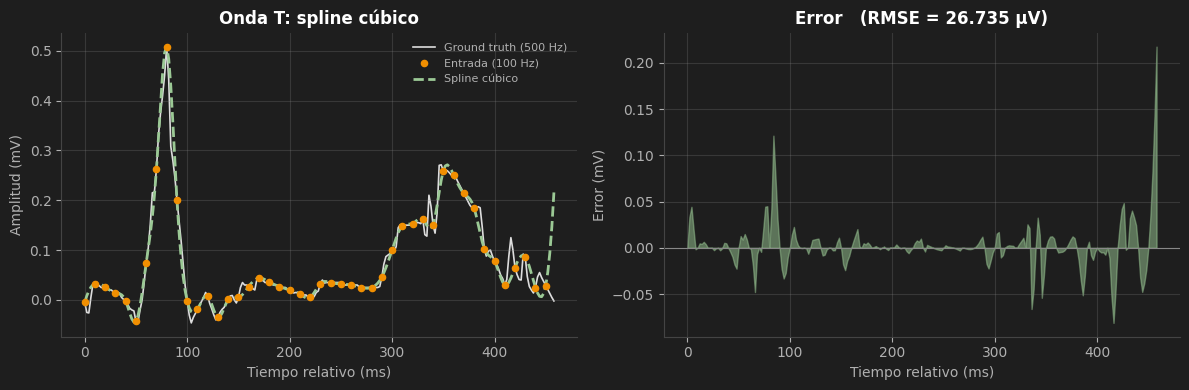

In [17]:
t_t, seg_t, _, _ = extract_segment(lead_hr, r, before_ms=80, after_ms=380)
t_t_sparse, seg_t_sparse = downsample(t_t, seg_t)

cs = CubicSpline(t_t_sparse, seg_t_sparse)
t_reconstructed = cs(t_t)

rmse_spline = np.sqrt(np.mean((t_reconstructed - seg_t) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1e1e1e')

for ax in axes:
    ax.set_facecolor('#1e1e1e')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444')
    ax.spines['bottom'].set_color('#444')
    ax.tick_params(colors='#b0b0b0')
    ax.grid(alpha=0.25, color='#888')
    ax.set_xlabel('Tiempo relativo (ms)', color='#b0b0b0')
    ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')

ax = axes[0]
ax.plot(t_t, seg_t, color='#dddddd', lw=1.2, label='Ground truth (500 Hz)', zorder=1)
ax.scatter(t_t_sparse, seg_t_sparse, color='#F18F01', s=20, zorder=3, label='Entrada (100 Hz)')
ax.plot(t_t, t_reconstructed, color='#9BC995', lw=2, linestyle='--', label='Spline cúbico', zorder=2)
ax.set_title('Onda T: spline cúbico', fontweight='bold', color='white')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)

ax = axes[1]
error_t = t_reconstructed - seg_t
ax.fill_between(t_t, error_t, alpha=0.5, color='#9BC995')
ax.axhline(0, color='#888', lw=0.8)
ax.set_title(f'Error   (RMSE = {rmse_spline*1000:.3f} µV)', fontweight='bold', color='white')
ax.set_ylabel('Error (mV)', color='#b0b0b0')
ax.set_xlabel('Tiempo relativo (ms)', color='#b0b0b0')

plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB'>5. Los tres métodos sobre un latido completo</h2>
<p style='color:#b0b0b0'>A partir de los 10 puntos que captura un ECG básico en la ventana del primer latido, reconstruimos los 50 puntos originales usando el método apropiado para cada región. La señal de 500 Hz original queda como referencia.</p>

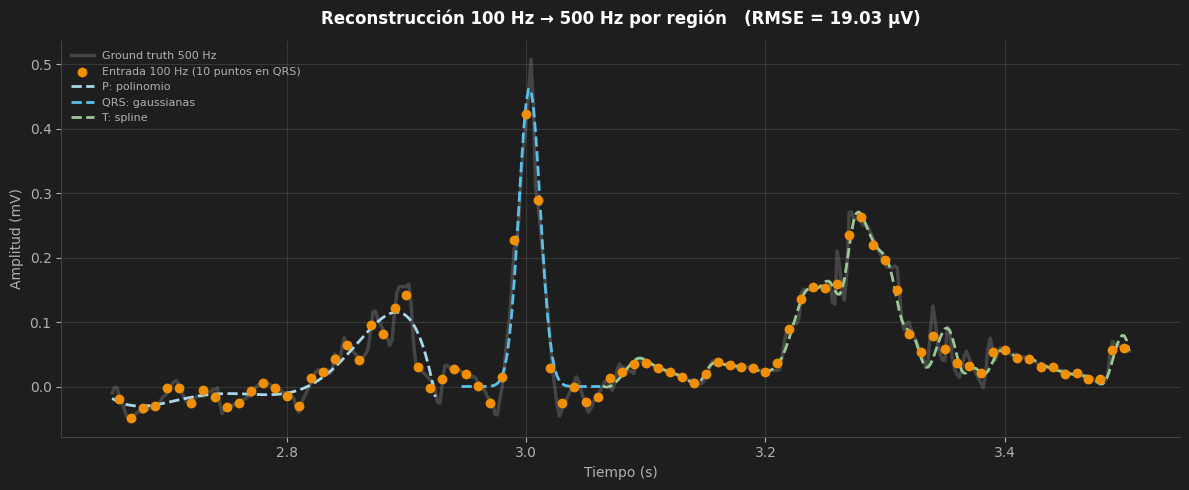

In [18]:
zoom_s = max(0, r_time - 0.35)
zoom_e = min(10.0, r_time + 0.5)
mask_hr = (t_hr >= zoom_s) & (t_hr <= zoom_e)
mask_lr = (t_lr >= zoom_s) & (t_lr <= zoom_e)

t_win = t_hr[mask_hr]
sig_win = lead_hr[mask_hr]

recon_win = sig_win.copy().astype(float)

t_rel_full = (t_win - zoom_s) * 1000
r_rel = (r_time - zoom_s) * 1000

def region_mask_rel(t_rel, from_ms, to_ms):
    return (t_rel >= from_ms) & (t_rel < to_ms)

p_mask = region_mask_rel(t_rel_full, 0, r_rel - 80)
if p_mask.sum() > 4:
    t_p_w = t_rel_full[p_mask]
    s_p_w = sig_win[p_mask]
    t_p_sp = t_p_w[::5]; s_p_sp = s_p_w[::5]
    if len(t_p_sp) >= 4:
        c = np.polyfit(t_p_sp, s_p_sp, min(6, len(t_p_sp)-1))
        recon_win[p_mask] = np.polyval(c, t_p_w)

q_mask = region_mask_rel(t_rel_full, r_rel - 60, r_rel + 60)
if q_mask.sum() > 4:
    t_q_w = t_rel_full[q_mask]
    s_q_w = sig_win[q_mask]
    t_q_sp = t_q_w[::5]; s_q_sp = s_q_w[::5]
    if len(t_q_sp) >= 3:
        try:
            A0 = float(s_q_w.max() - s_q_w.min())
            popt, _ = curve_fit(gauss_sum, t_q_sp, s_q_sp, p0=[A0, r_rel, 15], maxfev=5000)
            recon_win[q_mask] = gauss_sum(t_q_w, *popt)
        except Exception:
            pass

t_mask = region_mask_rel(t_rel_full, r_rel + 60, 1000)
if t_mask.sum() > 4:
    t_t_w = t_rel_full[t_mask]
    s_t_w = sig_win[t_mask]
    t_t_sp = t_t_w[::5]; s_t_sp = s_t_w[::5]
    if len(t_t_sp) >= 4:
        try:
            cs2 = CubicSpline(t_t_sp, s_t_sp)
            recon_win[t_mask] = cs2(t_t_w)
        except Exception:
            pass

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

ax.plot(t_win, sig_win, color='#444444', lw=2.5, label='Ground truth 500 Hz', zorder=1)
ax.scatter(t_lr[mask_lr], lead_lr[mask_lr], color='#F18F01', s=50, zorder=4, label='Entrada 100 Hz (10 puntos en QRS)', linewidths=0)

for mask_r, color, label in [
    (p_mask, '#A8D8EA', 'P: polinomio'),
    (q_mask, '#5BC0EB', 'QRS: gaussianas'),
    (t_mask, '#9BC995', 'T: spline')]:
    ax.plot(t_win[mask_r], recon_win[mask_r], color=color, lw=2, linestyle='--', zorder=3, label=label)

rmse_total = np.sqrt(np.mean((recon_win - sig_win) ** 2))
ax.set_title(f'Reconstrucción 100 Hz → 500 Hz por región   (RMSE = {rmse_total*1000:.2f} µV)',
             fontweight='bold', color='white', pad=12)
ax.set_xlabel('Tiempo (s)', color='#b0b0b0')
ax.set_ylabel('Amplitud (mV)', color='#b0b0b0')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8, loc='upper left')
ax.tick_params(colors='#b0b0b0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')
ax.grid(alpha=0.25, color='#888')
plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB'>6. Por qué el error no lo es todo</h2>
<p style='color:#b0b0b0'>El RMSE mide cuánto se aleja la curva reconstruida de la original punto a punto. Pero en diagnóstico cardíaco hay métricas más importantes que el error cuadrático: la posición del pico R, la duración del intervalo QTc, la pendiente del segmento ST. Si un infarto eleva el ST 1.5 mV y nuestra reconstrucción lo reporta en 1.4 mV, el error cuadrático es pequeño pero el diagnóstico sigue siendo correcto. Si lo baja a 0.5 mV, el diagnóstico desaparece.</p>
<p style='color:#b0b0b0'>Por eso el proyecto evaluará dos cosas por separado:</p>
<ol style='color:#b0b0b0'>
<li><strong>Error de señal</strong> (RMSE, MAE): qué tan cerca queda la curva reconstruida de la curva real.</li>
<li><strong>Preservación diagnóstica</strong>: ¿los marcadores clínicos (posición del pico R, intervalo QTc, elevación del ST) calculados sobre la señal reconstruida coinciden con los calculados sobre la señal real?</li>
</ol>
<blockquote style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); color:#e8c97a; padding:10px 14px; margin:8px 0'>
PTB-XL es el único dataset público con etiquetas de cardiólogo, par 100 Hz / 500 Hz y escala suficiente (21,799 registros) para hacer este doble análisis. Eso es lo que lo hace irremplazable para este proyecto.
</blockquote>

<h2 style='color:#5BC0EB'>7. El selector automático</h2>
<p style='color:#b0b0b0'>La segmentación por región (P, QRS, T) se hace automáticamente a partir del pico R, que es el punto de mayor amplitud y el más sencillo de detectar. El sistema detecta el pico, calcula las ventanas temporales estándar basadas en fisiología cardíaca, y despacha cada segmento al método que le corresponde.</p>

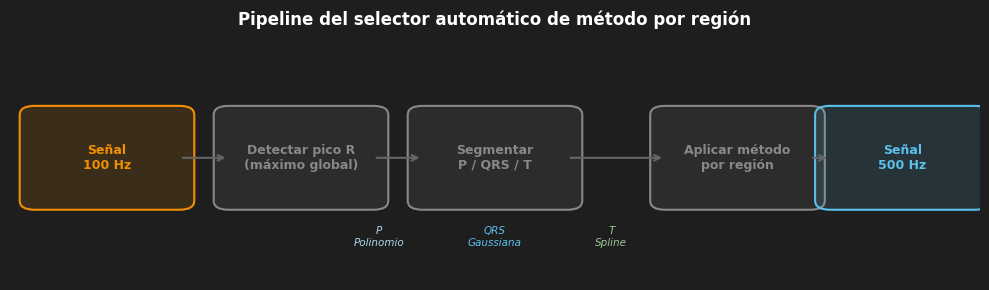

In [19]:
fig, ax = plt.subplots(figsize=(10, 3))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

steps = [
    (1.0, 'Señal\n100 Hz',          '#F18F01'),
    (3.0, 'Detectar pico R\n(máximo global)',  '#888888'),
    (5.0, 'Segmentar\nP / QRS / T',  '#888888'),
    (7.5, 'Aplicar método\npor región',        '#888888'),
    (9.2, 'Señal\n500 Hz',           '#5BC0EB')]

for x, label, color in steps:
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.75, 1.3), 1.5, 1.4,
        boxstyle='round,pad=0.15', linewidth=1.5,
        edgecolor=color, facecolor=color + '22'))
    ax.text(x, 2.0, label, ha='center', va='center',
            color=color, fontsize=9, fontweight='bold')

for i in range(len(steps) - 1):
    x1 = steps[i][0] + 0.75
    x2 = steps[i+1][0] - 0.75
    ax.annotate('', xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=dict(arrowstyle='->', color='#666', lw=1.5))

for region, x_off, color_r in [('P\nPolinomio', 5.0 - 1.2, '#A8D8EA'),
                                ('QRS\nGaussiana', 5.0, '#5BC0EB'),
                                ('T\nSpline', 5.0 + 1.2, '#9BC995')]:
    ax.text(x_off, 0.7, region, ha='center', va='center',
            color=color_r, fontsize=7.5, style='italic')

ax.set_title('Pipeline del selector automático de método por región', fontweight='bold', color='white', pad=8)
plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB'>8. Resumen del proyecto</h2>

<table style='color:#b0b0b0; border-collapse:collapse; width:100%'>
<thead><tr>
<th style='text-align:left; border-bottom:1px solid #444; padding:6px 10px; color:#5BC0EB'>Fase</th>
<th style='text-align:left; border-bottom:1px solid #444; padding:6px 10px; color:#5BC0EB'>Qué hacemos</th>
<th style='text-align:left; border-bottom:1px solid #444; padding:6px 10px; color:#5BC0EB'>Dataset usado</th>
</tr></thead>
<tbody>
<tr><td style='padding:6px 10px; border-bottom:1px solid #333'>1. EDA</td><td style='padding:6px 10px; border-bottom:1px solid #333'>Explorar distribución, cargar señales, visualizar las tres regiones</td><td style='padding:6px 10px; border-bottom:1px solid #333'>500 registros descargados</td></tr>
<tr><td style='padding:6px 10px; border-bottom:1px solid #333'>2. Motivación del dataset</td><td style='padding:6px 10px; border-bottom:1px solid #333'>Demostrar los tres métodos sobre señal real, justificar la elección de PTB-XL</td><td style='padding:6px 10px; border-bottom:1px solid #333'>500 registros descargados</td></tr>
<tr><td style='padding:6px 10px; border-bottom:1px solid #333'>3. Pipeline de reconstrucción</td><td style='padding:6px 10px; border-bottom:1px solid #333'>Implementar el selector automático, optimizar parámetros por método</td><td style='padding:6px 10px; border-bottom:1px solid #333'>500 registros</td></tr>
<tr><td style='padding:6px 10px; border-bottom:1px solid #333'>4. Evaluación cuantitativa</td><td style='padding:6px 10px; border-bottom:1px solid #333'>RMSE por región, preservación de marcadores diagnósticos (QTc, ST, pico R)</td><td style='padding:6px 10px; border-bottom:1px solid #333'>&ge;200 por clase diagnóstica</td></tr>
<tr><td style='padding:6px 10px'>5. Análisis por diagnóstico</td><td style='padding:6px 10px'>¿La reconstrucción es más difícil en infarto que en ritmo normal?</td><td style='padding:6px 10px'>Dataset completo (21,799)</td></tr>
</tbody>
</table>

<blockquote style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); color:#e8c97a; padding:10px 14px; margin:16px 0'>
<strong>Impacto esperado:</strong> si el sistema puede reconstruir la curva de 500 Hz desde la de 100 Hz con error clínicamente tolerable en la posición de los picos, se abre la posibilidad de usar equipos básicos de 5× menor costo para diagnóstico de infarto, fibrilación auricular y bloqueo de rama en clínicas rurales o de recursos limitados.
</blockquote>